In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression
import random

# 🧹Limpeza de dados

In [6]:
import platform
print(platform.architecture())


('64bit', 'WindowsPE')


In [7]:
base_data = pd.read_excel("dataframe/BD_Atlas.xlsx")

In [4]:
base_data

,Protocolo_S2iD,Nome_Municipio,Sigla_UF,regiao,Data_Registro,Data_Evento,Cod_Cobrade,tipologia,descricao_tipologia,grupo_de_desastre,...,PEPL_Ensino (R$),PEPL_total_publico,PEPR_Descricao,PEPR_Agricultura (R$),PEPR_Pecuária (R$),PEPR_Indústria (R$),PEPR_Comércio (R$),PEPR_Serviços (R$),PEPR_total_privado,PE_PLePR
0,SC-D-4215406-14110-19910107,Salto Veloso,SC,Sul,1991-01-07,1991-01-07,14110,4,Estiagem e Seca,Climatológico,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,RS-D-4313102-14110-19910112,Nova Palma,RS,Sul,1991-01-12,1991-01-12,14110,4,Estiagem e Seca,Climatológico,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,RS-D-4304952-14110-19910115,Caseiros,RS,Sul,1991-01-15,1991-01-15,14110,4,Estiagem e Seca,Climatológico,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SC-D-4208609-14110-19910115,Jaborá,SC,Sul,1991-01-15,1991-01-15,14110,4,Estiagem e Seca,Climatológico,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SC-D-4207650-14110-19910118,Iporã do Oeste,SC,Sul,1991-01-18,1991-01-18,14110,4,Estiagem e Seca,Climatológico,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71924,SP-F-3508702-12100-20241231,Caconde,SP,Sudeste,2024-12-31,2024-12-31,12100,7,Inundações,Hidrológico,...,0.0,0.0,Dimensões de danos a serem avaliadas,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71925,SP-F-3553401-13214-20241231,Tanabi,SP,Sudeste,2025-01-03,2024-12-31,13214,13,Chuvas Intensas,Hidrológico,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71926,SC-F-4215059-13213-20241231,Rio Rufino,SC,Sul,2025-01-02,2024-12-31,13213,5,Granizo,Meteorológico,...,0.0,0.0,NÃO HOUVE NENHUM EFEITO O EVENTO OCORRIDO,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71927,MG-F-3138708-13214-20241231,Luminárias,MG,Sudeste,2025-01-02,2024-12-31,13214,13,Chuvas Intensas,Hidrológico,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


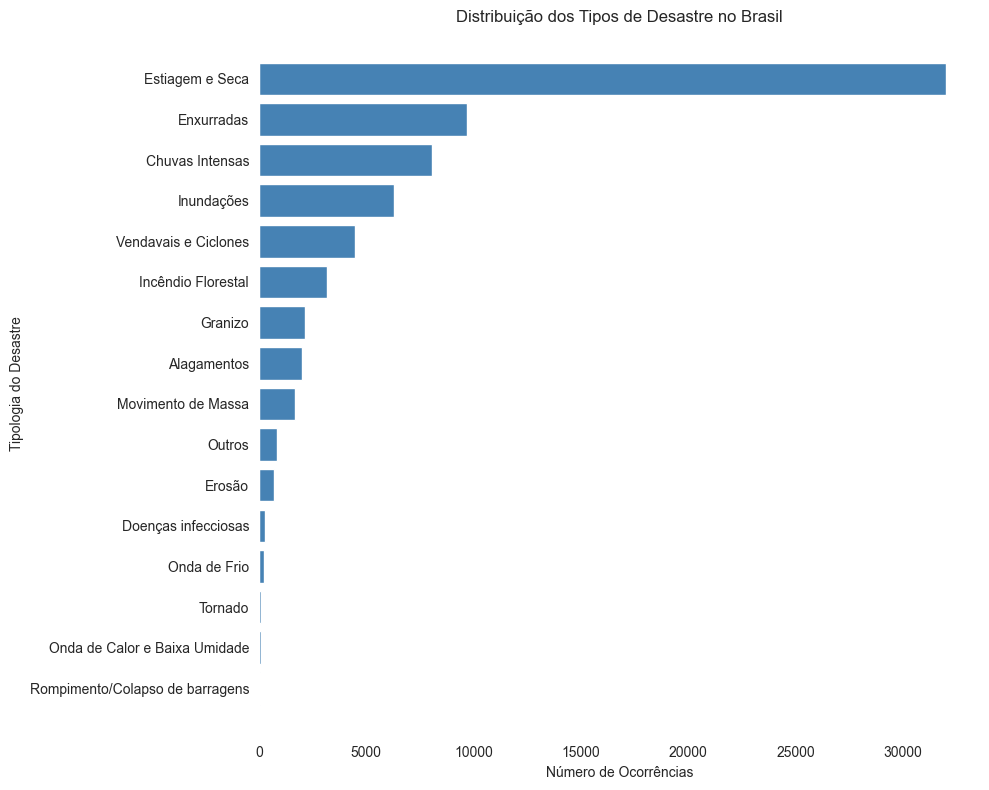

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8), facecolor='white')
tipologia_counts = base_data['descricao_tipologia'].value_counts().sort_values()

plt.figure(figsize=(10, 8))
plt.barh(tipologia_counts.index, tipologia_counts.values)
plt.xlabel('Número de Ocorrências')
plt.ylabel('Tipologia do Desastre')
plt.title('Distribuição dos Tipos de Desastre no Brasil')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


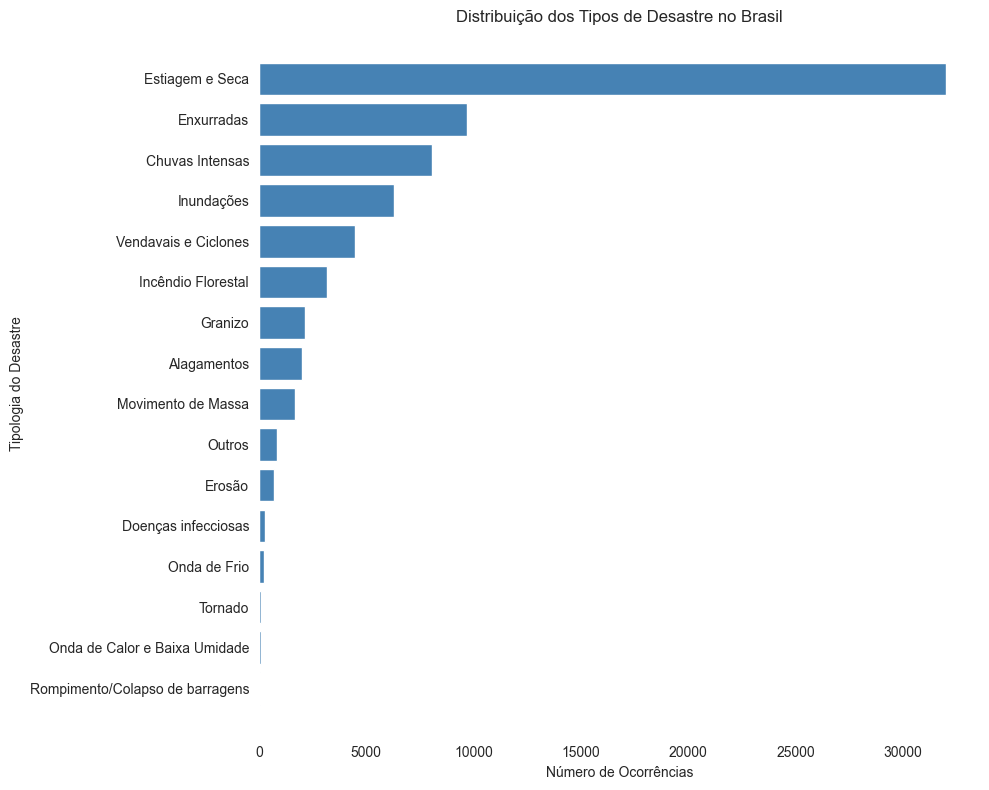

In [10]:
# Recriar o gráfico com fundo branco
plt.figure(figsize=(10, 8), facecolor='white')
plt.barh(tipologia_counts.index, tipologia_counts.values, color='steelblue')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Tipologia do Desastre')
plt.title('Distribuição dos Tipos de Desastre no Brasil')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_facecolor('white')  # Cor de fundo do gráfico
plt.show()


In [14]:
data = base_data.copy()

In [15]:
# Removendo keys desnecessarias
trash = ['Protocolo_S2iD','Cod_Cobrade', 'Data_Registro', 'Cod_IBGE_Mun', 'Setores Censitários', 'DM_Descricao', "DA_Incêndi parques/APA's/APP's",
         'DA_Dimi/exauri hídrico', 'DA_Polui/cont do solo', 'DA_Polui/cont da água', 'DA_Polui/cont do ar', 'DA_Descricao', 'PEPR_Descricao',
         'PEPL_Descricao', 'DH_Descricao']
data = data.drop(columns = trash)

In [16]:
import re

def normalize_column_names(df):
    df.columns = [
        re.sub(r'\W+', '_', col)  # Substitui qualquer caractere "não palavra" por underscore
        .strip('_')               # Remove underscores nas extremidades
        for col in df.columns
    ]
    return df

# Normalizando antes do upload
df = normalize_column_names(data)

In [18]:
data.to_csv("main.csv")

---

In [53]:
# Label Encoding
label_cols = ['Status', 'grupo_de_desastre']
label_maps = {}

for col in label_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))  # Salva o mapeamento

# One-Hot Encoding com compatibilidade
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop=None)
encoded = ohe.fit_transform(data[['descricao_tipologia']].astype(str))

ohe_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['descricao_tipologia']))
ohe_df.index = data.index

data = pd.concat([data.drop(columns=['descricao_tipologia']), ohe_df], axis=1)

# Mapeamento do LabelEncoder
for col, mapping in label_maps.items():
    print(f"\n🔤 Mapeamento de LabelEncoder para '{col}':")
    for original, encoded in mapping.items():
        print(f"  '{original}' → {encoded}")

data


🔤 Mapeamento de LabelEncoder para 'Status':
  'Reconhecido' → 0
  'Registro' → 1

🔤 Mapeamento de LabelEncoder para 'grupo_de_desastre':
  'Climatológico' → 0
  'Hidrológico' → 1
  'Meteorológico' → 2
  'Outros' → 3


,Nome_Municipio,Sigla_UF,regiao,Data_Evento,tipologia,grupo_de_desastre,Status,DH_MORTOS,DH_FERIDOS,DH_ENFERMOS,...,descricao_tipologia_Granizo,descricao_tipologia_Incêndio Florestal,descricao_tipologia_Inundações,descricao_tipologia_Movimento de Massa,descricao_tipologia_Onda de Calor e Baixa Umidade,descricao_tipologia_Onda de Frio,descricao_tipologia_Outros,descricao_tipologia_Rompimento/Colapso de barragens,descricao_tipologia_Tornado,descricao_tipologia_Vendavais e Ciclones
0,Salto Veloso,SC,Sul,1991-01-07,4,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Nova Palma,RS,Sul,1991-01-12,4,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Caseiros,RS,Sul,1991-01-15,4,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Jaborá,SC,Sul,1991-01-15,4,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Iporã do Oeste,SC,Sul,1991-01-18,4,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71924,Caconde,SP,Sudeste,2024-12-31,7,1,1,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71925,Tanabi,SP,Sudeste,2024-12-31,13,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71926,Rio Rufino,SC,Sul,2024-12-31,5,2,1,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71927,Luminárias,MG,Sudeste,2024-12-31,13,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
data.to_csv("dataframe/Silver_data.csv", index=False)

# ⛰️ Seq. Monte carlo

In [76]:
df = pd.read_csv('dataframe/Silver_data.csv', parse_dates=['Data_Evento'])

In [77]:
df['ano'] = df['Data_Evento'].dt.year

In [81]:
df

,Nome_Municipio,Sigla_UF,regiao,Data_Evento,tipologia,descricao_tipologia,grupo_de_desastre,Status,DH_MORTOS,DH_FERIDOS,...,PEPL_Ensino (R$),PEPL_total_publico,PEPR_Agricultura (R$),PEPR_Pecuária (R$),PEPR_Indústria (R$),PEPR_Comércio (R$),PEPR_Serviços (R$),PEPR_total_privado,PE_PLePR,ano
0,Salto Veloso,SC,Sul,1991-01-07,4,Estiagem e Seca,Climatológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1991
1,Nova Palma,RS,Sul,1991-01-12,4,Estiagem e Seca,Climatológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1991
2,Caseiros,RS,Sul,1991-01-15,4,Estiagem e Seca,Climatológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1991
3,Jaborá,SC,Sul,1991-01-15,4,Estiagem e Seca,Climatológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1991
4,Iporã do Oeste,SC,Sul,1991-01-18,4,Estiagem e Seca,Climatológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71924,Caconde,SP,Sudeste,2024-12-31,7,Inundações,Hidrológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
71925,Tanabi,SP,Sudeste,2024-12-31,13,Chuvas Intensas,Hidrológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
71926,Rio Rufino,SC,Sul,2024-12-31,5,Granizo,Meteorológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
71927,Luminárias,MG,Sudeste,2024-12-31,13,Chuvas Intensas,Hidrológico,Registro,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024


In [ ]:

features = df.select_dtypes(include=[np.number]).columns.tolist()
features.remove('ano')  # Evita conflito na hora do reset_index

# Agrupa corretamente
agrupado = df.groupby(['regiao', 'ano'])[features].sum().reset_index()
modelos = {}
desvios = {}

for regiao in agrupado['regiao'].unique():
    modelos[regiao] = {}
    desvios[regiao] = {}
    df_reg = agrupado[agrupado['regiao'] == regiao]

    for var in features:
        X = df_reg[['ano']]
        y = df_reg[var]
        modelo = LinearRegression().fit(X, y)
        y_pred = modelo.predict(X)

        modelos[regiao][var] = modelo
        desvios[regiao][var] = np.std(y - y_pred)


def simular_ano():
    ano_simulado = random.choice([2025, 2026, 2027])
    resultado = {'ano': ano_simulado}
    total_eventos = 0

    for regiao in agrupado['regiao'].unique():
        for var in features:
            modelo = modelos[regiao][var]
            media = modelo.predict([[ano_simulado]])[0]
            sigma = desvios[regiao][var]

            valor_simulado = np.random.normal(loc=media, scale=sigma)
            resultado[f'{regiao}_{var}'] = max(0, valor_simulado)  # evitar valores negativos

        # contar desastres como número de linhas por região/ano
        total_eventos += df[(df['ano'] == ano_simulado) & (df['regiao'] == regiao)].shape[0]

    resultado['total_eventos'] = total_eventos
    return resultado

# 5. Rodar simulações
simulacoes = [simular_ano() for _ in range(10000)]
df_simulado = pd.DataFrame(simulacoes)

# Exibir totais de desastres por região
col_eventos = [col for col in df_simulado.columns if col.endswith('_DH_total_danos_humanos_diretos')]
df_simulado['total_danos_humanos'] = df_simulado[col_eventos].sum(axis=1)

print(df_simulado.head())

C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users